# Sistem Monitoring dan Deteksi Dini Risiko Burnout pada Mahasiswa Berbasis Data Harian

Proyek ini bertujuan untuk membangun sistem monitoring berbasis data yang dapat membantu mahasiswa memantau kondisi hariannya dan mendeteksi indikasi risiko burnout secara lebih dini. Sistem ini menggunakan data terkait kondisi akademik, psikologis, pola tidur, aktivitas fisik, dukungan sosial, serta indikator lain yang relevan dengan risiko burnout mahasiswa.

Sistem yang dikembangkan berfungsi sebagai alat bantu monitoring dan deteksi dini, bukan sebagai alat diagnosis medis atau psikologis.

Burnout pada mahasiswa merupakan kondisi yang dapat muncul akibat tekanan akademik, tuntutan tugas, tekanan ujian, pola istirahat yang kurang baik, serta faktor psikologis dan sosial lainnya. Jika tidak dipantau sejak awal, burnout dapat berdampak pada konsentrasi, motivasi belajar, produktivitas, kesejahteraan diri, hingga risiko akademik.

Berdasarkan permasalahan tersebut, proyek ini dirancang untuk membantu mahasiswa memantau kondisi hariannya secara lebih terstruktur melalui sistem monitoring berbasis data. Analisis data dilakukan untuk memahami faktor-faktor yang berkaitan dengan burnout dan mendukung pengembangan sistem deteksi dini risiko burnout pada mahasiswa.

## Pertanyaan Bisnis:

- **Pertanyaan 1:** Bagaimana distribusi tingkat risiko burnout mahasiswa berdasarkan kategori risk level pada data harian yang digunakan?

- **Pertanyaan 2:** Bagaimana perbedaan rata-rata burnout score pada setiap tingkat academic year mahasiswa berdasarkan data harian yang digunakan?

- **Pertanyaan 3:** Faktor harian apa saja yang memiliki hubungan paling kuat dengan burnout score mahasiswa berdasarkan data harian yang digunakan?

- **Pertanyaan 4:** Bagaimana perbedaan rata-rata kondisi harian mahasiswa pada setiap kategori risk level berdasarkan stress level, exam pressure, sleep hours, physical activity, social support, dan screen time?

- **Pertanyaan 5:** Bagaimana hubungan antara burnout score, mental health index, dan dropout risk pada mahasiswa berdasarkan data harian yang digunakan?

## Import Library

Pada tahap ini dilakukan import library yang dibutuhkan untuk proses analisis data, visualisasi, preprocessing, feature selection, standardisasi, dan pengembangan model machine learning.

In [ ]:
import gdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from google.colab import files
import scipy.stats as stats

# Data Wrangling


# Gathering Data

Tahap ini dilakukan untuk memuat dataset yang akan digunakan dalam proyek.

In [ ]:
# Mengimport dataset
file_id = "1XpaH2MadDM4le3TERwcEigzNFfrNuxgO"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

df_full = pd.read_csv("data.csv")



Downloading...
From (original): https://drive.google.com/uc?id=1XpaH2MadDM4le3TERwcEigzNFfrNuxgO
From (redirected): https://drive.google.com/uc?id=1XpaH2MadDM4le3TERwcEigzNFfrNuxgO&confirm=t&uuid=ed9c46c7-f85e-4568-a933-91dc9e572988
To: /content/data.csv
100%|██████████| 294M/294M [00:05<00:00, 54.0MB/s]


In [ ]:
# Melihat struktur dataset
df_full.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


# Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data untuk mengetahui apakah terdapat missing value, data duplikat, penulisan kategori yang tidak konsisten, nilai negatif, dan outlier sebelum data digunakan pada tahap analisis.

In [ ]:
# Melihat keseluruhan dataset
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [ ]:
df_full.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [ ]:
# Melihat missing value dataset
df_full.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0


In [ ]:
# Melihat data duplikat
dup = df_full.duplicated().sum()
print("Jumlah Data Duplikat:",dup)

Jumlah Data Duplikat: 0


In [ ]:
# Mengecek penulisan kategori yang tidak konsisten.
categorical_cols = ['gender', 'risk_level']

for col in categorical_cols:
    print(f"\nKolom: {col}")
    print(df_full[col].value_counts())


Kolom: gender
gender
Female    480070
Male      479643
Other      40287
Name: count, dtype: int64

Kolom: risk_level
risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64


In [ ]:
# Mengecek nilai negatif
numeric_cols = df_full.select_dtypes(include='number').columns

for col in numeric_cols:
    negative_count = (df_full[col] < 0).sum()
    print(f"{col}: {negative_count} nilai negatif")

age: 0 nilai negatif
academic_year: 0 nilai negatif
study_hours_per_day: 0 nilai negatif
exam_pressure: 0 nilai negatif
academic_performance: 0 nilai negatif
stress_level: 0 nilai negatif
anxiety_score: 0 nilai negatif
depression_score: 0 nilai negatif
sleep_hours: 0 nilai negatif
physical_activity: 0 nilai negatif
social_support: 0 nilai negatif
screen_time: 0 nilai negatif
internet_usage: 0 nilai negatif
financial_stress: 0 nilai negatif
family_expectation: 0 nilai negatif
burnout_score: 0 nilai negatif
mental_health_index: 0 nilai negatif
dropout_risk: 0 nilai negatif


In [ ]:
# Mengecek jumlah outlier
for col in numeric_cols:
    Q1 = df_full[col].quantile(0.25)
    Q3 = df_full[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_full[(df_full[col] < lower_bound) | (df_full[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outlier")

age: 0 outlier
academic_year: 0 outlier
study_hours_per_day: 3491 outlier
exam_pressure: 2809 outlier
academic_performance: 6944 outlier
stress_level: 3287 outlier
anxiety_score: 3409 outlier
depression_score: 3351 outlier
sleep_hours: 0 outlier
physical_activity: 0 outlier
social_support: 0 outlier
screen_time: 3507 outlier
internet_usage: 3583 outlier
financial_stress: 0 outlier
family_expectation: 3454 outlier
burnout_score: 3735 outlier
mental_health_index: 4290 outlier
dropout_risk: 6675 outlier


## Cleaning Data

Tahap cleaning data dilakukan untuk menangani masalah kualitas data yang ditemukan pada tahap assessing data. Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing value dan data duplikat. Oleh karena itu, proses cleaning difokuskan pada penanganan outlier pada fitur numerik agar data lebih stabil untuk dianalisis pada tahap EDA dan pemodelan.

In [ ]:
# Membersihkan outlier fitur
outlier_cols_fitur = ['study_hours_per_day', 'exam_pressure','academic_performance','stress_level','anxiety_score',
                'depression_score','screen_time','internet_usage','family_expectation']

df_clean = df_full.copy()
for col in outlier_cols_fitur:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

  outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
  print(f"{col}: {len(outliers)} outlier")

study_hours_per_day: 0 outlier
exam_pressure: 0 outlier
academic_performance: 0 outlier
stress_level: 0 outlier
anxiety_score: 0 outlier
depression_score: 0 outlier
screen_time: 0 outlier
internet_usage: 0 outlier
family_expectation: 0 outlier


**Insight:**

- Dataset tidak memiliki missing value dan data duplikat, sehingga tidak diperlukan proses imputasi maupun penghapusan data duplikat.
- Penulisan kategori pada fitur kategorikal sudah konsisten, sehingga tidak diperlukan penyeragaman label kategori.
- Outlier ditangani menggunakan metode IQR dengan teknik pembatasan nilai ekstrem. Dengan metode ini, nilai ekstrem disesuaikan ke batas wajar tanpa menghapus baris data.
- Setelah proses cleaning, seluruh fitur yang dibersihkan sudah memiliki 0 outlier berdasarkan batas IQR yang digunakan.

## Exploratory Data Analysis (EDA)

Tujuan utama dari tahap ini adalah untuk memahami distribusi data, mengidentifikasi hubungan antarvariabel, dan mencari wawasan awal yang relevan dengan monitoring serta deteksi dini risiko burnout pada mahasiswa.




In [ ]:
df_eda = df_clean.copy()
df_eda.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [ ]:
# Melihat informasi struktur data EDA
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [ ]:
# Melihat ringkasan statistik data numerik
df_eda.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,4.999613,5.999836,70.998833,4.244925,2.984842,1.273159,6.501713,3.011153,4.999724,5.016705,5.035777,5.002920,5.984614,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.983005,1.545288,5.623971,1.674465,1.505072,1.215647,1.472972,1.463679,1.976536,1.954423,2.150707,1.976426,1.957150,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.783746,55.720875,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.590296,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,10.387863,10.000000,86.280974,8.809771,7.151868,5.208196,10.000000,7.000000,10.000000,10.401759,11.030413,10.000000,10.000000,10.000000,10.000000,9.326226


**Insight:**

- Dataset memiliki 1.000.000 baris dan 20 kolom dengan seluruh kolom memiliki jumlah data non-null yang lengkap, sehingga tidak terdapat missing value pada tahap ini.
- Sebagian besar fitur berupa data numerik, sedangkan fitur kategorikal utama adalah `gender` dan `risk_level`.
- Nilai pada fitur seperti `sleep_hours`, `stress_level`, `exam_pressure`, `burnout_score`, `mental_health_index`, dan `dropout_risk` masih berada pada skala asli, sehingga data masih mudah diinterpretasikan untuk kebutuhan EDA.
- Data ini sudah dapat digunakan untuk melihat distribusi risiko burnout, hubungan antarvariabel, serta pola kondisi harian mahasiswa sebelum masuk ke tahap encoding dan standardisasi.

In [ ]:
# Melihat distribusi gender
df_eda["gender"].value_counts()

,count
gender,
Female,480070
Male,479643
Other,40287


In [ ]:
# Melihat distribusi academic year
df_eda["academic_year"].value_counts()

,count
academic_year,
3,250433
4,250010
2,249886
1,249671


In [ ]:
# Melihat distribusi risk level
df_eda["risk_level"].value_counts()

,count
risk_level,
Low,766645
Medium,218275
High,15080


In [ ]:
# Menentukan fitur utama yang relevan dengan risiko burnout
main_features = [
    "burnout_score",
    "mental_health_index",
    "dropout_risk",
    "stress_level",
    "exam_pressure",
    "sleep_hours",
    "physical_activity",
    "social_support",
    "screen_time"
]

main_features = [col for col in main_features if col in df_eda.columns]

df_eda[main_features].describe()

,burnout_score,mental_health_index,dropout_risk,stress_level,exam_pressure,sleep_hours,physical_activity,social_support,screen_time
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.784073,7.023073,1.324896,4.244925,5.999836,6.501713,3.011153,4.999724,5.016705
std,1.664035,1.310698,1.342727,1.674465,1.545288,1.472972,1.463679,1.976536,1.954423
min,0.000000,1.309745,0.000000,0.000000,1.783746,3.000000,0.000000,0.000000,1.000000
25%,0.124810,6.141553,0.000000,3.102593,4.944647,5.491047,1.990596,3.650029,3.651138
50%,1.496505,7.074414,1.009531,4.244029,5.998906,6.501938,3.000619,4.999017,5.003518
75%,2.889473,7.962169,2.173661,5.385464,7.051914,7.514642,4.011208,6.349751,6.351386
max,10.000000,10.000000,9.326226,8.809771,10.000000,10.000000,7.000000,10.000000,10.401759


**Insight:**

- Berdasarkan distribusi kategori, data memiliki komposisi yang cukup seimbang pada fitur `gender` dan `academic_year`. Jumlah mahasiswa Female dan Male hampir sama, yaitu sekitar 480 ribu dan 479 ribu data, sedangkan kategori Other berjumlah sekitar 40 ribu data. Pada `academic_year`, jumlah data tiap tingkat juga relatif seimbang, yaitu sekitar 249–250 ribu data. Hal ini menunjukkan bahwa dataset cukup representatif untuk melihat pola burnout berdasarkan karakteristik mahasiswa.

- Berdasarkan distribusi `risk_level`, mayoritas mahasiswa berada pada kategori Low risk dengan 766.645 data, diikuti Medium risk sebanyak 218.275 data, dan High risk sebanyak 15.080 data. Meskipun kategori High risk memiliki jumlah paling kecil, kelompok ini tetap penting diperhatikan karena menunjukkan indikasi risiko burnout yang lebih tinggi. Kelompok Medium risk juga perlu dipantau karena dapat menjadi kelompok yang berpotensi meningkat risikonya apabila kondisi harian memburuk.

- Berdasarkan statistik fitur utama, rata-rata `burnout_score` sebesar 1,78 dan rata-rata `mental_health_index` sebesar 7,02 menunjukkan bahwa secara umum kondisi mahasiswa dalam dataset cenderung berada pada risiko burnout rendah dan indeks kesehatan mental yang cukup baik. Namun, adanya nilai maksimum `burnout_score` hingga 10 dan `dropout_risk` hingga sekitar 9,33 menunjukkan bahwa tetap terdapat sebagian mahasiswa dengan kondisi risiko tinggi. Fitur seperti `stress_level`, `exam_pressure`, `sleep_hours`, `physical_activity`, `social_support`, dan `screen_time` relevan untuk dianalisis lebih lanjut karena berkaitan langsung dengan tujuan monitoring dan deteksi dini risiko burnout.

In [ ]:
# Menghitung korelasi antarvariabel numerik
numeric_columns = df_eda.select_dtypes(include=["int64", "float64"]).columns

correlation_matrix = df_eda[numeric_columns].corr()

correlation_matrix

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
age,1.000000,0.000043,-0.000611,-0.000503,0.000805,-0.000793,-0.000245,-0.001686,-0.001298,-0.000132,-0.000351,0.000613,0.001074,-0.001369,-0.001239,-0.001016,0.000946,-0.001895
academic_year,0.000043,1.000000,0.000810,0.000248,0.000520,0.001156,0.001110,0.001199,-0.001716,-0.000965,0.000839,0.001112,0.001216,-0.000758,-0.000850,0.000555,-0.001332,-0.001220
study_hours_per_day,-0.000611,0.000810,1.000000,0.766187,0.388233,0.352955,0.269090,0.218641,-0.003265,0.000326,0.000585,-0.000771,-0.001653,0.000588,0.001028,0.335002,-0.335015,0.187274
exam_pressure,-0.000503,0.000248,0.766187,1.000000,0.126998,0.458897,0.350344,0.284782,-0.001817,0.000242,0.000826,-0.000070,-0.000904,0.000499,0.000814,0.434604,-0.435866,0.243561
academic_performance,0.000805,0.000520,0.388233,0.126998,1.000000,0.059653,0.045382,0.035803,-0.001554,-0.000844,0.000208,-0.001014,-0.001090,-0.000169,-0.000617,0.057040,-0.056285,0.032039
stress_level,-0.000793,0.001156,0.352955,0.458897,0.059653,1.000000,0.760729,0.622259,-0.263354,-0.173986,-0.000296,-0.001239,-0.001933,0.467350,0.347311,0.752423,-0.949062,0.553422
anxiety_score,-0.000245,0.001110,0.269090,0.350344,0.045382,0.760729,1.000000,0.476188,-0.200473,-0.131937,-0.000547,-0.001228,-0.001483,0.353894,0.263817,0.667865,-0.868398,0.461199
depression_score,-0.001686,0.001199,0.218641,0.284782,0.035803,0.622259,0.476188,1.000000,-0.165058,-0.109625,-0.365110,0.000037,-0.000245,0.291893,0.214723,0.642311,-0.763167,0.653694
sleep_hours,-0.001298,-0.001716,-0.003265,-0.001817,-0.001554,-0.263354,-0.200473,-0.165058,1.000000,-0.000144,0.000076,-0.000482,-0.001021,0.000055,-0.000136,-0.371386,0.250408,-0.191171
physical_activity,-0.000132,-0.000965,0.000326,0.000242,-0.000844,-0.173986,-0.131937,-0.109625,-0.000144,1.000000,0.001670,0.001692,0.001186,-0.000501,0.000926,-0.110074,0.165397,-0.070918


In [ ]:
# Melihat korelasi awal terhadap burnout score
burnout_corr = correlation_matrix["burnout_score"].sort_values(ascending=False)

burnout_corr

,burnout_score
burnout_score,1.000000
stress_level,0.752423
dropout_risk,0.689748
anxiety_score,0.667865
depression_score,0.642311
exam_pressure,0.434604
study_hours_per_day,0.335002
financial_stress,0.295702
family_expectation,0.217879
academic_performance,0.057040


**Insight:**

- Berdasarkan korelasi awal terhadap `burnout_score`, variabel yang memiliki hubungan positif paling kuat adalah `stress_level` sebesar 0,752, diikuti `dropout_risk` sebesar 0,690, `anxiety_score` sebesar 0,668, dan `depression_score` sebesar 0,642. Hal ini menunjukkan bahwa semakin tinggi stres, risiko dropout, kecemasan, dan gejala depresi, maka burnout score cenderung ikut meningkat. Selain itu, `exam_pressure`, `study_hours_per_day`, `financial_stress`, dan `family_expectation` juga memiliki korelasi positif, sehingga faktor akademik, finansial, dan ekspektasi keluarga tetap relevan untuk dianalisis lebih lanjut.

- Variabel yang memiliki hubungan negatif paling kuat dengan `burnout_score` adalah `mental_health_index` sebesar -0,797, diikuti `sleep_hours` sebesar -0,371, `social_support` sebesar -0,230, dan `physical_activity` sebesar -0,110. Artinya, semakin baik indeks kesehatan mental, durasi tidur, dukungan sosial, dan aktivitas fisik, maka burnout score cenderung lebih rendah. Pola ini sesuai dengan tujuan proyek karena faktor-faktor tersebut dapat menjadi indikator penting dalam sistem monitoring risiko burnout.

- Beberapa variabel seperti `academic_year`, `age`, `internet_usage`, dan `screen_time` memiliki korelasi yang sangat kecil terhadap `burnout_score`. Hal ini menunjukkan bahwa variabel tersebut belum terlihat memiliki hubungan linear yang kuat dengan burnout score pada analisis awal. Namun, variabel tersebut masih dapat dianalisis lebih lanjut pada tahap Visualization & Explanatory Analysis apabila berkaitan dengan pertanyaan bisnis atau kebutuhan fitur aplikasi.

**Insight EDA:**

- Dataset hasil cleaning memiliki 1.000.000 baris dan 20 kolom dengan seluruh kolom memiliki data non-null yang lengkap. Sebagian besar fitur berupa data numerik, sedangkan fitur kategorikal utama adalah `gender` dan `risk_level`. Selain itu, `academic_year` dapat diperlakukan sebagai fitur kategori ordinal karena merepresentasikan tingkat tahun akademik mahasiswa.

- Distribusi data menunjukkan bahwa komposisi `gender` dan `academic_year` cukup seimbang. Jumlah mahasiswa Female dan Male hampir sama, sedangkan kategori Other tetap terwakili dalam dataset. Pada `academic_year`, jumlah data tiap tingkat juga relatif merata, sehingga data cukup baik untuk digunakan dalam analisis perbandingan antar tingkat tahun akademik.

- Distribusi `risk_level` menunjukkan bahwa mayoritas mahasiswa berada pada kategori Low risk, diikuti Medium risk, dan sebagian kecil berada pada kategori High risk. Meskipun kategori High risk memiliki jumlah paling sedikit, kelompok ini tetap penting untuk diperhatikan karena menunjukkan indikasi risiko burnout yang lebih tinggi.

- Korelasi awal terhadap `burnout_score` menunjukkan bahwa faktor seperti `stress_level`, `dropout_risk`, `anxiety_score`, `depression_score`, `exam_pressure`, `study_hours_per_day`, dan `financial_stress` memiliki hubungan positif dengan burnout score. Sementara itu, `mental_health_index`, `sleep_hours`, `social_support`, dan `physical_activity` memiliki hubungan negatif dengan burnout score. Hasil EDA ini menjadi dasar untuk tahap Visualization & Explanatory Analysis yang akan menjawab pertanyaan bisnis secara lebih spesifik.


## Visualization & Explanatory Analysis

Tahap visualisasi dilakukan untuk menyajikan hasil analisis dalam bentuk grafik agar pola data lebih mudah dipahami. Pada tahap ini, setiap visualisasi disusun berdasarkan pertanyaan bisnis yang telah ditentukan sehingga hasilnya dapat memberikan insight yang lebih jelas mengenai monitoring dan deteksi dini risiko burnout mahasiswa.

### Pertanyaan 1: Bagaimana distribusi tingkat risiko burnout mahasiswa berdasarkan kategori risk level pada data harian yang digunakan?

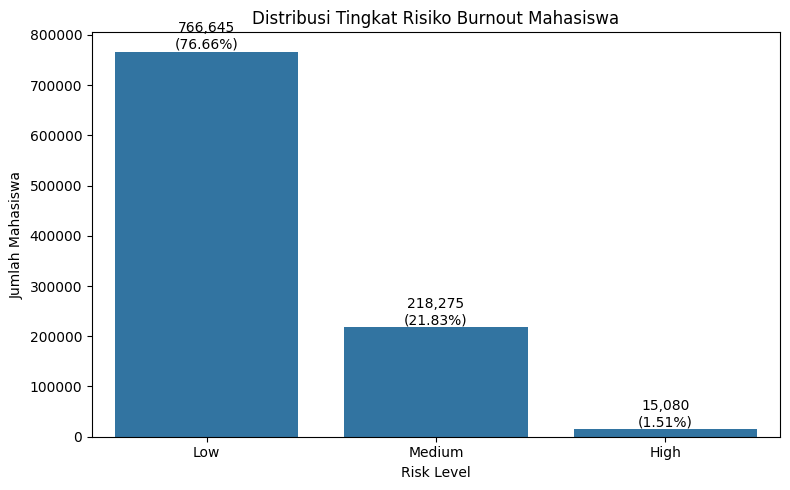

In [ ]:
# Visualisasi distribusi risk level
risk_order = ["Low", "Medium", "High"]

risk_summary = df_eda["risk_level"].value_counts().reindex(risk_order).reset_index()
risk_summary.columns = ["risk_level", "jumlah_mahasiswa"]
risk_summary["persentase"] = (
    risk_summary["jumlah_mahasiswa"] / risk_summary["jumlah_mahasiswa"].sum() * 100
).round(2)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=risk_summary,
    x="risk_level",
    y="jumlah_mahasiswa",
    order=risk_order
)

plt.title("Distribusi Tingkat Risiko Burnout Mahasiswa")
plt.xlabel("Risk Level")
plt.ylabel("Jumlah Mahasiswa")

for i, row in risk_summary.iterrows():
    ax.text(
        i,
        row["jumlah_mahasiswa"],
        f'{row["jumlah_mahasiswa"]:,}\n({row["persentase"]}%)',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan visualisasi distribusi `risk_level`, mayoritas mahasiswa berada pada kategori **Low risk**, yaitu sebanyak **766.645 data** atau sekitar **76,66%** dari keseluruhan data. Kategori **Medium risk** berjumlah **218.275 data** atau sekitar **21,83%**, sedangkan kategori **High risk** berjumlah **15.080 data** atau sekitar **1,51%**.

- Pola ini menunjukkan bahwa sebagian besar mahasiswa dalam dataset berada pada tingkat risiko burnout rendah. Namun, kelompok **Medium risk** dan **High risk** tetap perlu diperhatikan karena keduanya merepresentasikan mahasiswa yang menunjukkan indikasi risiko burnout lebih tinggi dibandingkan kelompok Low risk.

- Hasil ini mendukung kebutuhan sistem monitoring burnout mahasiswa, karena sistem dapat membantu mahasiswa mengetahui tingkat risikonya secara lebih awal. Kelompok Medium risk dapat menjadi perhatian untuk pencegahan dini, sedangkan kelompok High risk dapat menjadi prioritas untuk diberikan peringatan atau rekomendasi tindak lanjut.

### Pertanyaan 2: Bagaimana perbedaan rata-rata burnout score pada setiap tingkat academic year mahasiswa berdasarkan data harian yang digunakan?

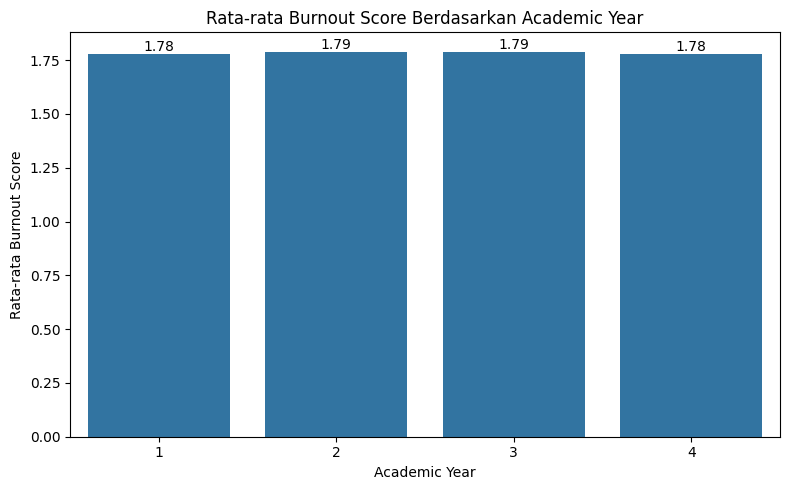

In [ ]:
# Visualisasi rata-rata burnout score berdasarkan academic year
burnout_by_academic_year = (
    df_eda.groupby("academic_year", as_index=False)["burnout_score"]
    .mean()
)

burnout_by_academic_year["burnout_score"] = burnout_by_academic_year["burnout_score"].round(2)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=burnout_by_academic_year,
    x="academic_year",
    y="burnout_score"
)

plt.title("Rata-rata Burnout Score Berdasarkan Academic Year")
plt.xlabel("Academic Year")
plt.ylabel("Rata-rata Burnout Score")

for i, row in burnout_by_academic_year.iterrows():
    ax.text(
        i,
        row["burnout_score"],
        f'{row["burnout_score"]:.2f}',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Insight:**


- Berdasarkan visualisasi, rata-rata `burnout_score` pada setiap tingkat `academic_year` terlihat sangat mirip. Academic year 1 dan 4 memiliki rata-rata burnout score sekitar **1,78**, sedangkan academic year 2 dan 3 sedikit lebih tinggi, yaitu sekitar **1,79**.

- Perbedaan nilai antar academic year sangat kecil, sehingga tingkat tahun akademik belum menunjukkan perbedaan burnout score yang signifikan secara deskriptif. Artinya, mahasiswa dari tahun akademik 1 sampai 4 memiliki kecenderungan burnout score yang relatif serupa dalam dataset ini.

- Hasil ini menunjukkan bahwa `academic_year` saja belum cukup kuat untuk dijadikan indikator utama dalam monitoring risiko burnout. Oleh karena itu, sistem perlu mempertimbangkan faktor lain yang lebih berkaitan dengan burnout, seperti `stress_level`, `exam_pressure`, `sleep_hours`, `physical_activity`, dan `social_support`.

### Pertanyaan 3: Faktor harian apa saja yang memiliki hubungan paling kuat dengan burnout score mahasiswa berdasarkan data harian yang digunakan?

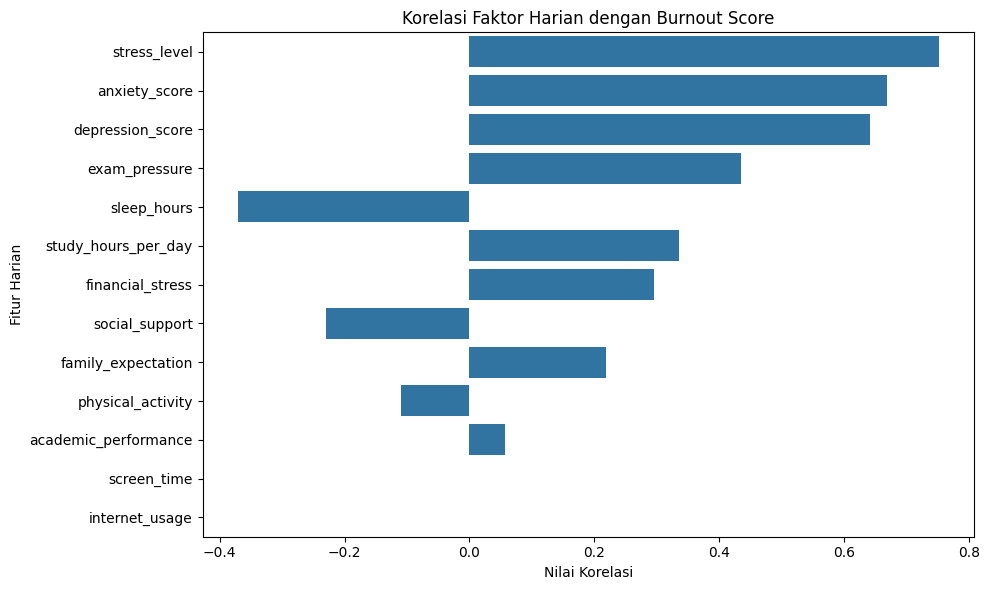

In [ ]:
# Visualisasi korelasi faktor harian dengan burnout score
daily_features = [
    "study_hours_per_day",
    "exam_pressure",
    "academic_performance",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_hours",
    "physical_activity",
    "social_support",
    "screen_time",
    "internet_usage",
    "financial_stress",
    "family_expectation"
]

daily_features = [col for col in daily_features if col in df_eda.columns]

burnout_correlation = (
    df_eda[daily_features + ["burnout_score"]]
    .corr()["burnout_score"]
    .drop("burnout_score")
)

burnout_correlation_summary = burnout_correlation.reindex(
    burnout_correlation.abs().sort_values(ascending=False).index
).reset_index()

burnout_correlation_summary.columns = ["feature", "correlation_with_burnout_score"]

burnout_correlation_summary["correlation_with_burnout_score"] = (
    burnout_correlation_summary["correlation_with_burnout_score"].round(3)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=burnout_correlation_summary,
    x="correlation_with_burnout_score",
    y="feature"
)

plt.title("Korelasi Faktor Harian dengan Burnout Score")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur Harian")
plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan visualisasi korelasi, faktor harian yang memiliki hubungan positif paling kuat dengan `burnout_score` adalah `stress_level`, diikuti oleh `anxiety_score`, `depression_score`, `exam_pressure`, `study_hours_per_day`, dan `financial_stress`. Hal ini menunjukkan bahwa semakin tinggi tingkat stres, kecemasan, depresi, tekanan ujian, durasi belajar, dan tekanan finansial, maka burnout score mahasiswa cenderung meningkat.

- Faktor seperti `sleep_hours`, `social_support`, dan `physical_activity` memiliki hubungan negatif dengan `burnout_score`. Artinya, durasi tidur yang lebih baik, dukungan sosial yang lebih tinggi, dan aktivitas fisik yang lebih baik cenderung berkaitan dengan burnout score yang lebih rendah.

- Hasil ini menunjukkan bahwa indikator psikologis, tekanan akademik, pola istirahat, dukungan sosial, dan aktivitas fisik merupakan faktor penting yang perlu dipertimbangkan dalam sistem monitoring risiko burnout. Namun, hubungan ini bersifat korelasi sehingga tidak dapat langsung disimpulkan sebagai hubungan sebab-akibat.

### Pertanyaan 4: Bagaimana perbedaan rata-rata kondisi harian mahasiswa pada setiap kategori risk level berdasarkan stress level, exam pressure, sleep hours, physical activity, social support, dan screen time?

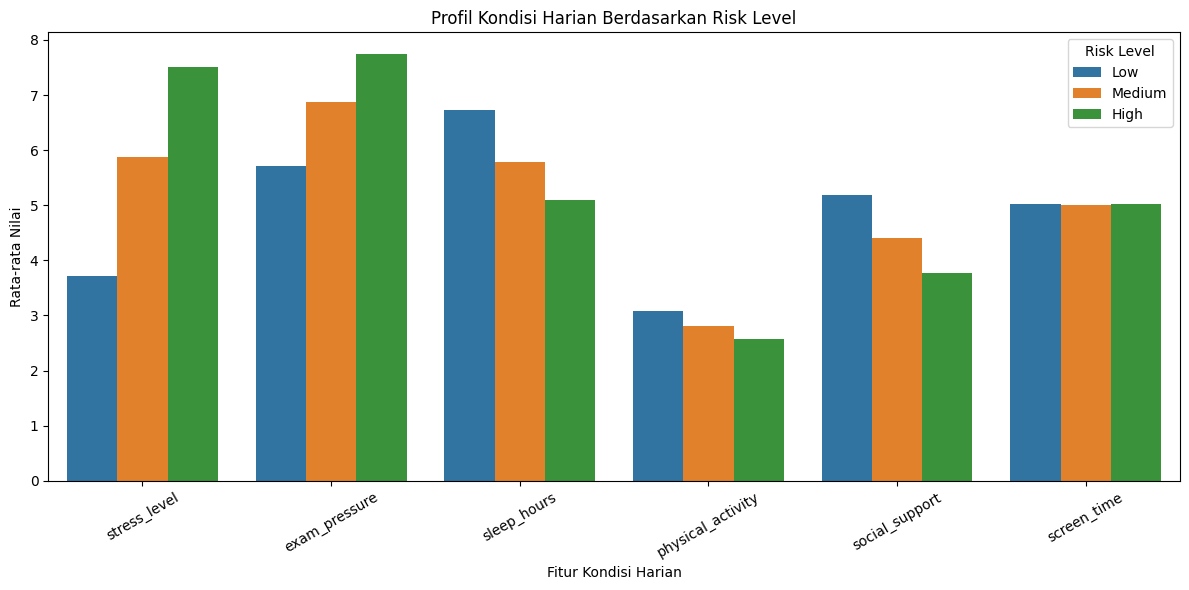

In [ ]:
# Visualisasi profil kondisi harian berdasarkan risk level
condition_features = [
    "stress_level",
    "exam_pressure",
    "sleep_hours",
    "physical_activity",
    "social_support",
    "screen_time"
]

condition_features = [col for col in condition_features if col in df_eda.columns]

risk_order = ["Low", "Medium", "High"]

risk_level_profile = (
    df_eda.groupby("risk_level")[condition_features]
    .mean()
    .round(2)
    .reindex(risk_order)
    .reset_index()
)

risk_profile_melted = risk_level_profile.melt(
    id_vars="risk_level",
    value_vars=condition_features,
    var_name="feature",
    value_name="average_value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=risk_profile_melted,
    x="feature",
    y="average_value",
    hue="risk_level",
    hue_order=risk_order
)

plt.title("Profil Kondisi Harian Berdasarkan Risk Level")
plt.xlabel("Fitur Kondisi Harian")
plt.ylabel("Rata-rata Nilai")
plt.xticks(rotation=30)
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan visualisasi profil kondisi harian, mahasiswa pada kategori **High risk** memiliki rata-rata `stress_level` dan `exam_pressure` paling tinggi dibandingkan kategori Medium dan Low risk. Hal ini menunjukkan bahwa mahasiswa dengan tingkat risiko burnout lebih tinggi cenderung memiliki tekanan psikologis dan tekanan akademik yang lebih besar.

- Sebaliknya, kelompok **High risk** memiliki rata-rata `sleep_hours`, `physical_activity`, dan `social_support` yang lebih rendah dibandingkan kelompok Low risk. Pola ini menunjukkan bahwa mahasiswa dengan risiko burnout lebih tinggi cenderung memiliki durasi tidur yang lebih rendah, aktivitas fisik yang lebih rendah, dan dukungan sosial yang lebih rendah.

- Rata-rata `screen_time` terlihat relatif mirip pada semua kategori risk level, sehingga pada data ini screen time tidak menunjukkan perbedaan yang terlalu menonjol antar tingkat risiko. Dengan demikian, indikator seperti stres, tekanan ujian, durasi tidur, aktivitas fisik, dan dukungan sosial terlihat lebih relevan untuk digunakan dalam monitoring risiko burnout mahasiswa.

### Pertanyaan 5: Bagaimana hubungan antara burnout score, mental health index, dan dropout risk pada mahasiswa berdasarkan data harian yang digunakan?

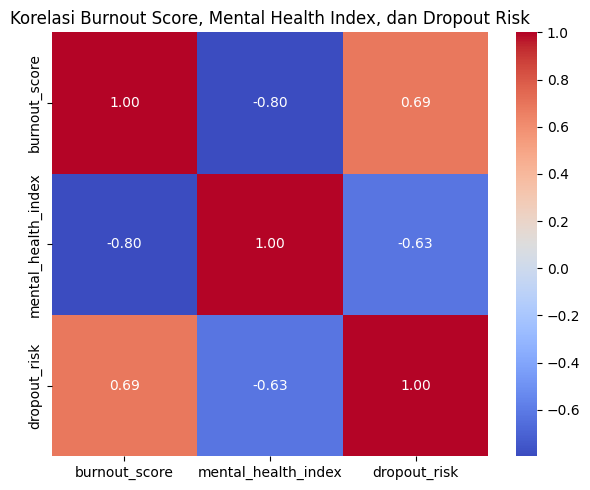

In [ ]:
# Visualisasi korelasi burnout score, mental health index, dan dropout risk
burnout_mental_dropout = df_eda[[
    "burnout_score",
    "mental_health_index",
    "dropout_risk"
]].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    burnout_mental_dropout,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Burnout Score, Mental Health Index, dan Dropout Risk")
plt.tight_layout()
plt.show()

**Insight:**

- Berdasarkan heatmap korelasi, `burnout_score` memiliki hubungan positif dengan `dropout_risk`, yaitu sekitar **0,69**. Artinya, semakin tinggi burnout score mahasiswa, risiko dropout cenderung ikut meningkat.

- `burnout_score` memiliki hubungan negatif yang kuat dengan `mental_health_index`, yaitu sekitar **-0,80**. Hal ini menunjukkan bahwa semakin tinggi burnout score, indeks kesehatan mental mahasiswa cenderung semakin rendah.

- Selain itu, `mental_health_index` juga memiliki hubungan negatif dengan `dropout_risk`, yaitu sekitar **-0,63**. Pola ini mendukung tujuan sistem sebagai alat bantu monitoring dan deteksi dini risiko burnout mahasiswa. Namun, hasil ini tetap perlu dipahami sebagai hubungan statistik, bukan sebagai diagnosis medis atau psikologis.

### Kesimpulan

- Visualisasi distribusi `risk_level` menunjukkan bahwa mayoritas mahasiswa berada pada kategori Low risk, tetapi kelompok Medium risk dan High risk tetap perlu dipantau karena menunjukkan indikasi risiko burnout yang lebih tinggi.

- Rata-rata `burnout_score` pada setiap `academic_year` terlihat relatif mirip, sehingga tingkat tahun akademik saja belum cukup kuat untuk menjadi indikator utama dalam monitoring risiko burnout mahasiswa.

- Faktor yang paling berkaitan positif dengan `burnout_score` adalah `stress_level`, `anxiety_score`, `depression_score`, `exam_pressure`, `study_hours_per_day`, dan `financial_stress`. Sementara itu, faktor yang berkaitan negatif adalah `sleep_hours`, `social_support`, dan `physical_activity`.

- Mahasiswa pada kategori High risk cenderung memiliki `stress_level` dan `exam_pressure` yang lebih tinggi, serta `sleep_hours`, `physical_activity`, dan `social_support` yang lebih rendah dibandingkan kategori Low risk.

- `burnout_score` memiliki hubungan positif dengan `dropout_risk` dan hubungan negatif dengan `mental_health_index`. Hasil ini mendukung pengembangan sistem sebagai alat bantu monitoring dan deteksi dini risiko burnout mahasiswa, bukan sebagai alat diagnosis medis atau psikologis.

## Feature Engineering

### Feature Selection Unsupervised (Manual)

In [ ]:
# Feature Engineering
df_fe = df_clean.copy()

# Drop kolom target yang tidak relevan dengan tujuan aplikasi
df_fe = df_fe.drop(columns=['dropout_risk'], errors='ignore')

print("Shape df_clean:", df_clean.shape)
print("Shape df_fe:", df_fe.shape)
df_fe.head()

Shape df_clean: (1000000, 20)
Shape df_fe: (1000000, 19)


,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low


**Insight:**
- Menghapus kolom risiko dropout karena tidak relevan dengan tujuan pembuatan web aplikasi

In [ ]:
# Menambahkan kolom untuk kategori mental_health_index
df_fe['mental_health_category'] = pd.cut(df_fe['mental_health_index'], bins=[0,4,7,10],labels=['Buruk','Sedang','Baik'],include_lowest=True)
df_fe.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,mental_health_category
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,Baik
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,Baik
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,Baik
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,Sedang
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,Baik


**Insight:**
- Menambahkan opsi output baru untuk pemodelan yang dihasilkan yaitu kategori mental health berdasarkan mental health index dengan kategori buruk, sedang, dan baik

### Encoding Variabel

In [ ]:
# Encoding untuk variabel kategori

# Encoding fitur gender menggunakan label encoding
label_encoder = LabelEncoder()
df_fe['gender'] = label_encoder.fit_transform(df_fe['gender'])

# Encoding fitur risk_level dan mental_health_category menggunakan manual ordinal encoding
risk_level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_fe['risk_level'] = df_fe['risk_level'].map(risk_level_mapping)

mental_health_mapping = {'Buruk': 0, 'Sedang': 1, 'Baik': 2}
df_fe['mental_health_category'] = df_fe['mental_health_category'].map(mental_health_mapping)

df_fe.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,mental_health_category
0,23,1,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,0,2
1,20,1,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,0,2
2,29,1,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,0,2
3,27,1,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,2,1
4,24,1,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,0,2


**Insight:**
- Melakukan label encoding pada variabel kategorik

In [ ]:
# Mapping untuk fitur kategori hasil encoding
gender_mapping = {
    kategori: kode
    for kode, kategori in enumerate(label_encoder.classes_)
}

print("Mapping gender:")
print(gender_mapping)

print("\nMapping risk_level:")
print(risk_level_mapping)

print("\nMapping mental_health_category:")
print(mental_health_mapping)

Mapping gender:
{'Female': 0, 'Male': 1, 'Other': 2}

Mapping risk_level:
{'Low': 0, 'Medium': 1, 'High': 2}

Mapping mental_health_category:
{'Buruk': 0, 'Sedang': 1, 'Baik': 2}


### Feature Selection Supervised

In [ ]:
# Fitur Selection

# Fitur awal yang berasal dari dataset asli
feature_cols = [
    'age',
    'gender',
    'academic_year',
    'study_hours_per_day',
    'exam_pressure',
    'academic_performance',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'sleep_hours',
    'physical_activity',
    'social_support',
    'screen_time',
    'internet_usage',
    'financial_stress',
    'family_expectation'
]

# Target regresi
regression_targets = [
    'burnout_score',
    'mental_health_index'
]

# Target klasifikasi
classification_targets = [
    'risk_level',
    'mental_health_category'
]

# Pastikan hanya kolom yang benar-benar ada
feature_cols = [col for col in feature_cols if col in df_fe.columns]

print("Jumlah fitur awal:", len(feature_cols))
print(feature_cols)

Jumlah fitur awal: 16
['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation']


In [ ]:
# Sampling agar proses feature selection tidak terlalu berat
sample_size = min(200000, len(df_fe))

df_sample = df_fe.sample(
    n=sample_size,
    random_state=42
)

X_sample = df_sample[feature_cols]

print("Shape data sampel:", df_sample.shape)
print("Shape fitur:", X_sample.shape)

Shape data sampel: (200000, 20)
Shape fitur: (200000, 16)


#### Feature Selection Menggunakan Metode Filter

In [ ]:
# Fitur Selection menggunakan filter_method

filter_results = {}

discrete_features = [
    col in ['age','gender', 'academic_year']
    for col in feature_cols
]
# Untuk target regresi
for target in regression_targets:
    y_sample = df_sample[target]

    scores = mutual_info_regression(
        X_sample,
        y_sample,
        discrete_features=discrete_features,
        random_state=42
    )

    result = pd.DataFrame({
        'feature': feature_cols,
        'mi_score': scores,
        'target': target,
        'method': 'Filter - Mutual Information'
    }).sort_values(by='mi_score', ascending=False)

    filter_results[target] = result

# Untuk target klasifikasi
for target in classification_targets:
    y_sample = df_sample[target]

    scores = mutual_info_classif(
        X_sample,
        y_sample,
        discrete_features=discrete_features,
        random_state=42
    )

    result = pd.DataFrame({
        'feature': feature_cols,
        'mi_score': scores,
        'target': target,
        'method': 'Filter - Mutual Information'
    }).sort_values(by='mi_score', ascending=False)

    filter_results[target] = result

# Menampilkan hasil fitur selection menggunakan filter_method
for target, result in filter_results.items():
    print(f"\nTop fitur berdasarkan Mutual Information untuk target: {target}")
    display(result.head(10))


Top fitur berdasarkan Mutual Information untuk target: burnout_score


,feature,mi_score,target,method
6,stress_level,0.445930,burnout_score,Filter - Mutual Information
7,anxiety_score,0.310394,burnout_score,Filter - Mutual Information
8,depression_score,0.259693,burnout_score,Filter - Mutual Information
4,exam_pressure,0.108587,burnout_score,Filter - Mutual Information
9,sleep_hours,0.079430,burnout_score,Filter - Mutual Information
3,study_hours_per_day,0.063967,burnout_score,Filter - Mutual Information
14,financial_stress,0.046167,burnout_score,Filter - Mutual Information
15,family_expectation,0.027823,burnout_score,Filter - Mutual Information
11,social_support,0.026854,burnout_score,Filter - Mutual Information
10,physical_activity,0.007238,burnout_score,Filter - Mutual Information



Top fitur berdasarkan Mutual Information untuk target: mental_health_index


,feature,mi_score,target,method
6,stress_level,1.254681,mental_health_index,Filter - Mutual Information
7,anxiety_score,0.722008,mental_health_index,Filter - Mutual Information
8,depression_score,0.441984,mental_health_index,Filter - Mutual Information
14,financial_stress,0.108405,mental_health_index,Filter - Mutual Information
4,exam_pressure,0.106793,mental_health_index,Filter - Mutual Information
3,study_hours_per_day,0.061981,mental_health_index,Filter - Mutual Information
15,family_expectation,0.059397,mental_health_index,Filter - Mutual Information
9,sleep_hours,0.029979,mental_health_index,Filter - Mutual Information
10,physical_activity,0.013737,mental_health_index,Filter - Mutual Information
11,social_support,0.008230,mental_health_index,Filter - Mutual Information



Top fitur berdasarkan Mutual Information untuk target: risk_level


,feature,mi_score,target,method
6,stress_level,0.220683,risk_level,Filter - Mutual Information
7,anxiety_score,0.159130,risk_level,Filter - Mutual Information
8,depression_score,0.144604,risk_level,Filter - Mutual Information
4,exam_pressure,0.060924,risk_level,Filter - Mutual Information
9,sleep_hours,0.042702,risk_level,Filter - Mutual Information
3,study_hours_per_day,0.033583,risk_level,Filter - Mutual Information
14,financial_stress,0.027774,risk_level,Filter - Mutual Information
11,social_support,0.018044,risk_level,Filter - Mutual Information
15,family_expectation,0.014985,risk_level,Filter - Mutual Information
10,physical_activity,0.004447,risk_level,Filter - Mutual Information



Top fitur berdasarkan Mutual Information untuk target: mental_health_category


,feature,mi_score,target,method
6,stress_level,0.507818,mental_health_category,Filter - Mutual Information
7,anxiety_score,0.366711,mental_health_category,Filter - Mutual Information
8,depression_score,0.275338,mental_health_category,Filter - Mutual Information
14,financial_stress,0.071959,mental_health_category,Filter - Mutual Information
4,exam_pressure,0.066578,mental_health_category,Filter - Mutual Information
15,family_expectation,0.040169,mental_health_category,Filter - Mutual Information
3,study_hours_per_day,0.038320,mental_health_category,Filter - Mutual Information
9,sleep_hours,0.020837,mental_health_category,Filter - Mutual Information
10,physical_activity,0.010299,mental_health_category,Filter - Mutual Information
11,social_support,0.004748,mental_health_category,Filter - Mutual Information


**Insight:**
- Fitur yang paling berpengaruh terhadap risiko burnout adalah stress_level, diikuti oleh anxiety_score dan depression_score. Hal ini menunjukkan bahwa tingkat burnout mahasiswa sangat erat kaitannya dengan kondisi psikologis utama, terutama stres. Selain faktor psikologis, exam_pressure dan sleep_hours juga memiliki kontribusi yang cukup terlihat. Tekanan ujian yang tinggi cenderung meningkatkan burnout, sedangkan jam tidur berhubungan dengan kemampuan pemulihan fisik dan mental mahasiswa. Faktor seperti financial_stress, family_expectation, dan social_support tetap berpengaruh, tetapi kontribusinya relatif lebih kecil dibanding variabel psikologis inti.
- Pada target mental health, fitur dengan pengaruh paling dominan kembali adalah stress_level. Ini mengindikasikan bahwa indeks kesehatan mental sangat sensitif terhadap tingkat stres mahasiswa. Selain itu, anxiety_score dan depression_score juga memberikan kontribusi besar, sehingga kesehatan mental mahasiswa dapat dipandang sebagai kombinasi dari kondisi stres, kecemasan, dan depresi. Menariknya, financial_stress memiliki pengaruh lebih besar dibanding beberapa target lain, menunjukkan bahwa tekanan finansial cukup memengaruhi kondisi kesehatan mental secara keseluruhan.

#### Feature Selection Menggunakan Metode Embedded

In [ ]:
# Fitur Selection menggunakan embedded_method

embedded_results = {}

# Untuk target regresi
for target in regression_targets:
    y_sample = df_sample[target]

    rf_regressor = RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )

    rf_regressor.fit(X_sample, y_sample)

    result = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_regressor.feature_importances_,
        'target': target,
        'method': 'Embedded - Random Forest'
    }).sort_values(by='importance', ascending=False)

    embedded_results[target] = result

# Untuk target klasifikasi
for target in classification_targets:
    y_sample = df_sample[target]

    rf_classifier = RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )

    rf_classifier.fit(X_sample, y_sample)

    result = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_classifier.feature_importances_,
        'target': target,
        'method': 'Embedded - Random Forest'
    }).sort_values(by='importance', ascending=False)

    embedded_results[target] = result

# Menampilkan hasil fitur selection menggunakan filter_method
for target, result in embedded_results.items():
    print(f"\nTop fitur berdasarkan Random Forest untuk target: {target}")
    display(result.head(10))


Top fitur berdasarkan Random Forest untuk target: burnout_score


,feature,importance,target,method
6,stress_level,0.745273,burnout_score,Embedded - Random Forest
11,social_support,0.074065,burnout_score,Embedded - Random Forest
9,sleep_hours,0.056663,burnout_score,Embedded - Random Forest
7,anxiety_score,0.040229,burnout_score,Embedded - Random Forest
4,exam_pressure,0.027087,burnout_score,Embedded - Random Forest
8,depression_score,0.026826,burnout_score,Embedded - Random Forest
3,study_hours_per_day,0.005329,burnout_score,Embedded - Random Forest
14,financial_stress,0.003839,burnout_score,Embedded - Random Forest
5,academic_performance,0.003808,burnout_score,Embedded - Random Forest
15,family_expectation,0.003762,burnout_score,Embedded - Random Forest



Top fitur berdasarkan Random Forest untuk target: mental_health_index


,feature,importance,target,method
6,stress_level,0.869649,mental_health_index,Embedded - Random Forest
7,anxiety_score,0.069760,mental_health_index,Embedded - Random Forest
8,depression_score,0.060488,mental_health_index,Embedded - Random Forest
4,exam_pressure,0.000012,mental_health_index,Embedded - Random Forest
11,social_support,0.000011,mental_health_index,Embedded - Random Forest
9,sleep_hours,0.000011,mental_health_index,Embedded - Random Forest
5,academic_performance,0.000010,mental_health_index,Embedded - Random Forest
15,family_expectation,0.000009,mental_health_index,Embedded - Random Forest
14,financial_stress,0.000009,mental_health_index,Embedded - Random Forest
3,study_hours_per_day,0.000008,mental_health_index,Embedded - Random Forest



Top fitur berdasarkan Random Forest untuk target: risk_level


,feature,importance,target,method
6,stress_level,0.304199,risk_level,Embedded - Random Forest
7,anxiety_score,0.182471,risk_level,Embedded - Random Forest
8,depression_score,0.179781,risk_level,Embedded - Random Forest
9,sleep_hours,0.079672,risk_level,Embedded - Random Forest
4,exam_pressure,0.060572,risk_level,Embedded - Random Forest
11,social_support,0.055197,risk_level,Embedded - Random Forest
3,study_hours_per_day,0.026533,risk_level,Embedded - Random Forest
14,financial_stress,0.022489,risk_level,Embedded - Random Forest
15,family_expectation,0.017239,risk_level,Embedded - Random Forest
10,physical_activity,0.015436,risk_level,Embedded - Random Forest



Top fitur berdasarkan Random Forest untuk target: mental_health_category


,feature,importance,target,method
6,stress_level,0.410171,mental_health_category,Embedded - Random Forest
7,anxiety_score,0.277340,mental_health_category,Embedded - Random Forest
8,depression_score,0.212295,mental_health_category,Embedded - Random Forest
14,financial_stress,0.030846,mental_health_category,Embedded - Random Forest
4,exam_pressure,0.019658,mental_health_category,Embedded - Random Forest
15,family_expectation,0.012644,mental_health_category,Embedded - Random Forest
3,study_hours_per_day,0.012290,mental_health_category,Embedded - Random Forest
11,social_support,0.006843,mental_health_category,Embedded - Random Forest
9,sleep_hours,0.005142,mental_health_category,Embedded - Random Forest
10,physical_activity,0.004544,mental_health_category,Embedded - Random Forest


**Insight:**
- Berdasarkan metode Random Forest, fitur yang paling dominan dalam memprediksi risiko burnout adalah stress_level dengan nilai importance yang sangat tinggi dibanding fitur lainnya. Hal ini menunjukkan bahwa tingkat stres menjadi faktor utama yang menentukan tingkat burnout mahasiswa. Terlihat juga bahwa social_support dan sleep_hours memiliki kontribusi yang lebih besar dibanding anxiety_score maupun depression_score. Ini mengindikasikan bahwa ketika model mempelajari pola secara keseluruhan, dukungan sosial dan kualitas istirahat berperan penting dalam membedakan tingkat burnout mahasiswa. Faktor akademik seperti exam_pressure juga tetap relevan, sedangkan variabel seperti financial_stress dan family_expectation memberikan pengaruh yang relatif kecil.
- Untuk target mental health, model Random Forest memperlihatkan bahwa pengelompokan kategori kesehatan mental terutama ditentukan oleh stress_level, anxiety_score, dan depression_score. Ketiga fitur ini memiliki importance yang jauh lebih tinggi dibanding fitur lain, sehingga menjadi faktor utama dalam membedakan kategori kesehatan mental mahasiswa. Selain itu, financial_stress menjadi faktor tambahan yang cukup penting dibanding variabel lainnya, menunjukkan bahwa tekanan finansial dapat memengaruhi perpindahan kategori kesehatan mental seseorang. Sementara itu, fitur seperti social_support, sleep_hours, dan physical_activity tetap memiliki pengaruh, tetapi kontribusinya relatif kecil dalam proses klasifikasi kategori kesehatan mental.

#### Hasil Feature Selection Supervised

In [ ]:
# Menghitung fitur yang keluar pada dua metode
vote_counter = {}

# Voting dari filter method
for target, result in filter_results.items():
    top_features = result.head(10)['feature'].tolist()

    for feature in top_features:
        vote_counter[feature] = vote_counter.get(feature, 0) + 1

# Voting dari embedded method
for target, result in embedded_results.items():
    top_features = result.head(10)['feature'].tolist()

    for feature in top_features:
        vote_counter[feature] = vote_counter.get(feature, 0) + 1

vote_table = pd.DataFrame({
    'feature': list(vote_counter.keys()),
    'vote_score': list(vote_counter.values())
}).sort_values(by='vote_score', ascending=False)

vote_table

,feature,vote_score
0,stress_level,8
1,anxiety_score,8
2,depression_score,8
3,exam_pressure,8
4,sleep_hours,8
5,study_hours_per_day,8
6,financial_stress,8
7,family_expectation,8
8,social_support,8
9,physical_activity,6


In [ ]:
# Memilih fitur berdasarkan voting
selected_features = vote_table.head(10)['feature'].tolist()

print("Fitur final terpilih:")
print(selected_features)

target_final = regression_targets + classification_targets

df_selected = df_fe[selected_features + target_final].copy()

print("Shape dataset awal:", df_fe.shape)
print("Shape dataset hasil feature selection:", df_selected.shape)

df_selected.head()

Fitur final terpilih:
['stress_level', 'anxiety_score', 'depression_score', 'exam_pressure', 'sleep_hours', 'study_hours_per_day', 'financial_stress', 'family_expectation', 'social_support', 'physical_activity']
Shape dataset awal: (1000000, 20)
Shape dataset hasil feature selection: (1000000, 14)


,stress_level,anxiety_score,depression_score,exam_pressure,sleep_hours,study_hours_per_day,financial_stress,family_expectation,social_support,physical_activity,burnout_score,mental_health_index,risk_level,mental_health_category
0,4.116950,2.275713,1.986730,6.487218,6.880545,5.596071,3.446626,3.586147,6.470080,2.728861,2.037344,7.074487,0,2
1,0.349489,0.000000,0.000000,5.631481,7.463339,5.597171,2.814039,5.478666,0.000000,3.690866,0.000000,9.860204,0,2
2,3.476177,2.425201,0.851996,6.015297,8.946670,2.580491,4.918515,6.068155,6.901725,3.296720,0.000000,7.626370,0,2
3,6.778843,4.512425,4.285645,6.684005,4.571380,4.607208,6.915885,6.557540,2.349857,2.065480,7.227651,4.649042,2,1
4,1.854595,1.102558,0.000000,4.010945,5.989324,2.186569,4.382820,5.934779,4.512921,4.026504,0.000000,8.927394,0,2


### Standarisasi Dataset

In [ ]:
# Membuat dataset versi standarisasi
df_scaled = df_selected.copy()

exclude_columns = ['burnout_score','mental_health_index','risk_level','mental_health_category']
# Menentukan fitur numerik yang akan distandardisasi
numeric_features_to_scale = [
    col for col in df_scaled.select_dtypes(include=['int64', 'float64']).columns
    if col not in exclude_columns
]

print("Fitur yang distandardisasi:")
print(numeric_features_to_scale,"\n")
print("="*350)

# Melakukan standarisasi
scaler = StandardScaler()

df_scaled[numeric_features_to_scale] = scaler.fit_transform(
    df_scaled[numeric_features_to_scale]
)

df_scaled.head()

Fitur yang distandardisasi:
['stress_level', 'anxiety_score', 'depression_score', 'exam_pressure', 'sleep_hours', 'study_hours_per_day', 'financial_stress', 'family_expectation', 'social_support', 'physical_activity'] 



,stress_level,anxiety_score,depression_score,exam_pressure,sleep_hours,study_hours_per_day,financial_stress,family_expectation,social_support,physical_activity,burnout_score,mental_health_index,risk_level,mental_health_category
0,-0.076427,-0.471159,0.586989,0.315399,0.257189,0.300785,-0.787429,-1.225490,0.743905,-0.192865,2.037344,7.074487,0,2
1,-2.326378,-1.983189,-1.047310,-0.238373,0.652848,0.301340,-1.107495,-0.258513,-2.529539,0.464387,0.000000,9.860204,0,2
2,-0.459101,-0.371837,-0.346452,0.010006,1.659881,-1.219928,-0.042706,0.042685,0.962290,0.195103,0.000000,7.626370,0,2
3,1.513271,1.014957,2.478094,0.442746,-1.310503,-0.197884,0.967892,0.292735,-1.340663,-0.646093,7.227651,4.649042,2,1
4,-1.427519,-1.250627,-1.047310,-1.287069,-0.347861,-1.418577,-0.313749,-0.025463,-0.246291,0.693698,0.000000,8.927394,0,2


## Export Dataset

In [ ]:
# Export dataset hasil cleaning
df_clean.to_csv('student_mental_health_clean.csv', index=False)

In [ ]:
# Export dataset hasil feature selection
df_selected.to_csv('student_mental_health_selected_features.csv', index=False)

# Export dataset versi standardisasi
df_scaled.to_csv('student_mental_health_scaled.csv', index=False)

## Analisis Statistika A/B Testing
A/B testing dalam project ini digunakan sebagai analisis perbandingan dua kelompok berdasarkan kategori risiko burnout mahasiswa. A/B testing diterapkan pada dataset utama dengan membandingkan kelompok mahasiswa yang memiliki risiko burnout medium dan risiko burnout high.
- Pada tahap A/B testing, penelitian ini membandingkan dua kelompok mahasiswa berdasarkan kategori risiko burnout, yaitu kelompok medium sebagai Group A dan kelompok high sebagai Group B.
- Perbandingan dilakukan terhadap beberapa metrik pendukung, yaitu stress level, social support, sleep, exam pressure, dan anxiety level. Pemilihan kelompok medium dan high dilakukan karena kedua kelompok tersebut berada pada area risiko yang perlu diperhatikan. Kelompok medium merepresentasikan mahasiswa yang mulai menunjukkan potensi burnout, sedangkan kelompok high merepresentasikan mahasiswa dengan risiko burnout yang lebih serius.
- Dengan membandingkan kedua kelompok tersebut, penelitian dapat mengidentifikasi faktor-faktor yang membedakan mahasiswa dengan risiko sedang dan tinggi, sehingga hasil analisis dapat digunakan sebagai dasar rekomendasi dalam

Hipotesis umum

H0: Tidak terdapat perbedaan rata-rata pada variabel yang diuji antara mahasiswa dengan risiko burnout medium dan high.

H1: Terdapat perbedaan rata-rata pada variabel yang diuji antara mahasiswa dengan risiko burnout medium dan high.

In [ ]:
# Membuat fungsi pengujian A/B testing menggunakan uji t
def ab_testing(df, metric, alpha=0.05) :
    """
    Fungsi A/B Testing untuk data normal.
    Menggunakan Independent Sample T-Test.
    Parameter:
    df = dataset yang digunakan
    metric = nama kolom yang akan diuji
    alpha = tingkat signifikansi (default 0.05)
    """
    hasil = []

    # Mengambil data Group A, yaitu mahasiswa dengan risk_level Medium
    grup_A = df[df['risk_level'] == 'Medium'][metric]
    # Mengambil data Group B, yaitu mahasiswa dengan risk_level High
    grup_B = df[df['risk_level'] == 'High'][metric]

    # Uji Levene digunakan untuk mengecek homogenitas varian
    # Jika levene_p > alpha, maka varians kedua kelompok dianggap sama
    levene_stat, levene_p = stats.levene(grup_A, grup_B)

    # Menentukan apakah t-test menggunakan asumsi varians sama atau tidak
    equal_var = levene_p > alpha

    # Menghitung rata - rata grup
    xbarA = grup_A.mean()
    xbarB = grup_B.mean()
    # Melakukan Uji t
    t, p_value = stats.ttest_ind(
            grup_A,
            grup_B,
            equal_var=equal_var
        )

    # Menentukan keputusan berdasarkan p-value
    if p_value < alpha:
            keputusan = "Tolak H0"

    else:
            keputusan = "Gagal Tolak H0"

    # Menyimpan hasil pengujian ke dalam dictionary
    hasil.append({
         "Levene p-value": round(levene_p, 4),
         "Rata-rata grup A": round(xbarA, 4),
         "Rata-rata grup B": round(xbarB, 4),
         "t-Statistic": round(t, 4),
         "P-Value": round(p_value, 4),
         "Keputusan": keputusan
    })

    return pd.DataFrame(hasil)

### A/B Testing Tingkat Stres Mahasiswa

**Hipotesis untuk tingkat stres**

H0: $\bar{x}_A = \bar{x}_B$ ( Tidak terdapat perbedaan rata-rata tingkat stres antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

H1: $\bar{x}_A \ne \bar{x}_B$ ( Terdapat perbedaan rata-rata tingkat stres antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

In [ ]:
# Melihat hasil uji
ab_testing_stress_level = ab_testing(df_clean, 'stress_level')

ab_testing_stress_level

,Levene p-value,Rata-rata grup A,Rata-rata grup B,t-Statistic,P-Value,Keputusan
0,0.0,5.8828,7.5117,-196.8159,0.0,Tolak H0


**Interpretasi:**

Berdasarkan hasil uji t, diperoleh nilai p-value lebih kecil dari  nilai alpha = 0,05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata tingkat stres yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi. Dengan demikian, tingkat stres dapat menjadi salah satu faktor pembeda antara mahasiswa yang berada pada kategori risiko burnout sedang dan tinggi. Mahasiswa dengan risiko burnout tinggi memiliki rata-rata tingkat stres yang lebih tinggi dibandingkan mahasiswa dengan risiko burnout sedang. Temuan ini mengindikasikan bahwa peningkatan risiko burnout berkaitan dengan tingkat stres yang lebih tinggi pada mahasiswa.

### A/B Testing Tingkat Dukungan Sosial

**Hipotesis untuk dukungan sosial**

H0: $\bar{x}_A = \bar{x}_B$ ( Tidak terdapat perbedaan rata-rata dukungan sosial antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

H1: $\bar{x}_A \ne \bar{x}_B$ ( Terdapat perbedaan rata-rata dukungan sosial antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

In [ ]:
# Melihat hasil uji
ab_testing_social_support = ab_testing(df_clean, 'social_support')

ab_testing_social_support

,Levene p-value,Rata-rata grup A,Rata-rata grup B,t-Statistic,P-Value,Keputusan
0,0.0002,4.4065,3.7744,40.1688,0.0,Tolak H0


**Interpretasi:**

Berdasarkan hasil uji t, diperoleh nilai p-value lebih kecil dari 0,05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata dukungan sosial yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi. Dengan demikian, dukungan sosial dapat menjadi salah satu faktor pembeda antara mahasiswa yang berada pada kategori risiko burnout sedang dan tinggi. Mahasiswa dengan risiko burnout tinggi memiliki rata-rata dukungan sosial yang lebih rendah dibandingkan mahasiswa dengan risiko burnout sedang. Temuan ini mengindikasikan bahwa rendahnya dukungan sosial berkaitan dengan tingginya risiko burnout pada mahasiswa.

### A/B Testing Durasi Tidur

**Hipotesis untuk durasi tidur**

H0: $\bar{x}_A = \bar{x}_B$ ( Tidak terdapat perbedaan rata-rata durasi tidur antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

H1: $\bar{x}_A \ne \bar{x}_B$ ( Terdapat perbedaan rata-rata durasi tidur antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

In [ ]:
# Melihat hasil uji
ab_testing_sleep_hours = ab_testing(df_clean, 'sleep_hours')

ab_testing_sleep_hours

,Levene p-value,Rata-rata grup A,Rata-rata grup B,t-Statistic,P-Value,Keputusan
0,0.0,5.7944,5.0883,65.5105,0.0,Tolak H0


**Interpretasi:**

Berdasarkan hasil uji t, diperoleh nilai p-value lebih kecil dari 0,05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata durasi tidur yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi. Dengan demikian, durasi tidur dapat menjadi salah satu faktor pembeda antara mahasiswa yang berada pada kategori risiko burnout sedang dan tinggi. Mahasiswa dengan risiko burnout tinggi memiliki rata-rata durasi tidur yang lebih rendah dibandingkan mahasiswa dengan risiko burnout sedang. Temuan ini mengindikasikan bahwa semakin tinggi risiko burnout, semakin rendah durasi tidur yang dimiliki mahasiswa.

### A/B Testing Tingkat Tekanan Ujian

**Hipotesis untuk tekanan ujian**

H0: $\bar{x}_A = \bar{x}_B$ ( Tidak terdapat perbedaan rata-rata tekanan ujian antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

H1: $\bar{x}_A \ne \bar{x}_B$ ( Terdapat perbedaan rata-rata tekanan ujian antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

In [ ]:
# Melihat hasil uji
ab_testing_exam_pressure = ab_testing(df_clean, 'exam_pressure')

ab_testing_exam_pressure

,Levene p-value,Rata-rata grup A,Rata-rata grup B,t-Statistic,P-Value,Keputusan
0,0.0,6.8685,7.7517,-79.9175,0.0,Tolak H0


**Interpretasi:**

Berdasarkan hasil uji t, diperoleh nilai p-value lebih kecil dari 0,05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata tekanan ujian yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi. Dengan demikian, tekanan ujian dapat menjadi salah satu faktor pembeda antara mahasiswa yang berada pada kategori risiko burnout sedang dan tinggi. Mahasiswa dengan risiko burnout tinggi memiliki rata-rata tekanan ujian yang lebih tinggi dibandingkan mahasiswa dengan risiko burnout sedang. Temuan ini mengindikasikan bahwa semakin tinggi tekanan ujian yang dirasakan mahasiswa, semakin besar pula kecenderungan mahasiswa berada pada kategori risiko burnout tinggi.

### A/B Testing Skor Kecemasan

**Hipotesis untuk skor kecemasan**

H0: $\bar{x}_A = \bar{x}_B$ ( Tidak terdapat perbedaan rata-rata skor kecemasan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi )

H1: $\bar{x}_A \ne \bar{x}_B$ ( Terdapat perbedaan rata-rata skor kecemasan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi)

In [ ]:
# Melihat hasil uji
ab_testing_anxiety_score = ab_testing(df_clean, 'anxiety_score')

ab_testing_anxiety_score

,Levene p-value,Rata-rata grup A,Rata-rata grup B,t-Statistic,P-Value,Keputusan
0,0.0,4.2933,5.6187,-148.1726,0.0,Tolak H0


**Interpretasi:**

Berdasarkan hasil uji t, diperoleh nilai p-value lebih kecil dari 0,05 sehingga H0 ditolak. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata skor kecemasan yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi. Dengan demikian, skor kecemasan dapat menjadi salah satu faktor pembeda antara mahasiswa yang berada pada kategori risiko burnout sedang dan tinggi. Mahasiswa dengan risiko burnout tinggi memiliki rata-rata skor kecemasan yang lebih tinggi dibandingkan mahasiswa dengan risiko burnout sedang. Temuan ini mengindikasikan bahwa semakin tinggi risiko burnout, semakin tinggi pula kecenderungan kecemasan yang dialami mahasiswa.

### Kesimpulan A/B Testing

Berdasarkan hasil A/B testing menggunakan Independent Sample T-Test, diperoleh bahwa seluruh metrik yang diuji memiliki nilai signifikansi lebih kecil dari 0,05. Dengan demikian, H0 ditolak pada setiap pengujian. Hal ini menunjukkan bahwa terdapat perbedaan rata-rata yang signifikan antara mahasiswa dengan risiko burnout sedang dan mahasiswa dengan risiko burnout tinggi.

Perbedaan tersebut terlihat pada lima aspek utama, yaitu tingkat stres, dukungan sosial, durasi tidur, tekanan ujian, dan skor kecemasan. Mahasiswa dengan risiko burnout tinggi cenderung memiliki tingkat stres, tekanan ujian, dan skor kecemasan yang lebih tinggi, serta memiliki dukungan sosial dan durasi tidur yang lebih rendah dibandingkan mahasiswa dengan risiko burnout sedang.

Dengan demikian, hasil A/B testing menunjukkan bahwa peningkatan risiko burnout tidak hanya berkaitan dengan tekanan akademik, tetapi juga dengan kondisi psikologis, pola istirahat, dan dukungan sosial mahasiswa. Temuan ini dapat digunakan sebagai dasar dalam pengembangan aplikasi, khususnya untuk memberikan rekomendasi yang berfokus pada pengelolaan stres, manajemen tekanan ujian, peningkatan kualitas tidur, penguatan dukungan sosial, serta pengelolaan kecemasan.